In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Данные
x = np.array([0.7, 1.1, 1.5, 1.9, 2.3, 2.8, 3.1, 3.8, 3.9, 4.3])
y = np.array([2.32, 1.02, 0.59, 0.35, 0.03, 0.29, 0.1, 0.13, 0.18, 0.09])

# y = Ax^A

In [3]:
def new_iter(vars, J, F):
    return vars - np.linalg.inv(J) @ F


def F(vars):
    a, A = vars
    eq1 = np.round(np.sum(y * np.exp(a * x)) - A * np.sum(np.exp(2 * a * x)), 3)
    eq2 = np.round(np.sum(x * y * np.exp(a * x)) - A * np.sum(x * np.exp(2 * a * x)), 3)
    return np.round(np.array([eq1, eq2]), 3)

# Якобиан системы уравнений
def J(vars):
    a, A = vars
    # Частные производные по a
    dF1_da = np.sum(y * x * np.exp(a * x)) - A * 2 * np.sum(x * np.exp(2 * a * x))
    dF1_dA = -np.sum(np.exp(2 * a * x))
    dF2_da = np.sum(x * y * x * np.exp(a * x)) - A * 2 * np.sum(x**2 * np.exp(2 * a * x))
    dF2_dA = -np.sum(x * np.exp(2 * a * x))
    return np.round(np.array([[dF1_da, dF1_dA],
                     [dF2_da, dF2_dA]]), 3)

In [ ]:
# Таблица результатов
results = []

# Начальные значения
def start_values():
    c_0 = np.round((np.sum(np.log(y)) * np.sum(np.log(x)) * np.sum(np.log(x)) * np.log(y) ) / ( 10 * np.sum(np.log(x)**2) - np.sum(np.log(x))**2 ), 3)
    c_1 = np.round((10 * np.sum(np.log(y) * np.log(x)) - np.sum(np.log(x) * np.sum(np.log(y)))) / ( 10 * np.sum(np.log(x)**2) - np.sum(np.log(x))**2 ), 3)
    return c_0, c_1

# Начальные значения
def second_values():
    c_0 = np.round(
        (np.sum(y**2 * np.log(y)) * np.sum(np.log(x)**2 * y**2 ) * np.sum(np.log(x)) * np.log(y) ) 
        / ( 10 * np.sum(np.log(x)**2) - np.sum(np.log(x))**2 ), 3)
    c_1 = np.round((10 * np.sum(np.log(y) * np.log(x)) - np.sum(np.log(x) * np.sum(np.log(y)))) / ( 10 * np.sum(np.log(x)**2) - np.sum(np.log(x))**2 ), 3)
    return c_0, c_1


start_values()

(array([-22.963,  -0.54 ,  14.397,  28.646,  95.682,  33.777,  62.829,
         55.67 ,  46.791,  65.704]),
 np.float64(-1.714))

In [43]:
df = pd.DataFrame({
        "x": x, 
        "y": y, 
        "ln(x)": np.log(x), 
        "ln(y)": np.log(y), 
        "ln^2(x)": np.log(x)**2, 
        "ln(y) ln(y)": np.log(y) * np.log(x) 
    })
name = df.keys()
df_text = pd.concat([df, pd.DataFrame(df[name[2:]].sum()).T]).fillna('')
df_latex = df_text.to_latex(float_format="%.3f").replace("\\\n", "\\ \hline\n")
print(df_latex)

\begin{tabular}{lllrrrr}
\toprule
 & x & y & ln(x) & ln(y) & ln^2(x) & ln(y) ln(y) \\ \hline
\midrule
0 & 0.700 & 2.320 & -0.357 & 0.842 & 0.127 & -0.300 \\ \hline
1 & 1.100 & 1.020 & 0.095 & 0.020 & 0.009 & 0.002 \\ \hline
2 & 1.500 & 0.590 & 0.405 & -0.528 & 0.164 & -0.214 \\ \hline
3 & 1.900 & 0.350 & 0.642 & -1.050 & 0.412 & -0.674 \\ \hline
4 & 2.300 & 0.030 & 0.833 & -3.507 & 0.694 & -2.921 \\ \hline
5 & 2.800 & 0.290 & 1.030 & -1.238 & 1.060 & -1.275 \\ \hline
6 & 3.100 & 0.100 & 1.131 & -2.303 & 1.280 & -2.605 \\ \hline
7 & 3.800 & 0.130 & 1.335 & -2.040 & 1.782 & -2.724 \\ \hline
8 & 3.900 & 0.180 & 1.361 & -1.715 & 1.852 & -2.334 \\ \hline
9 & 4.300 & 0.090 & 1.459 & -2.408 & 2.128 & -3.512 \\ \hline
0 &  &  & 7.934 & -13.926 & 9.509 & -16.556 \\ \hline
\bottomrule
\end{tabular}



In [59]:

sum_df = np.round(df.sum(axis=0)[2:], 3)
a = np.round(np.array(
    [
        [10, sum_df[0]], 
        [sum_df[0], sum_df[2]]
    ]), 3)
b = np.round(np.array([
    [sum_df[1]], 
    [sum_df[3]]
    ]), 3)
new_vars = np.round(np.linalg.solve(a, b).T, 3)
print("подставялеем данные из таблицы реши следующую систему")
print(print_cases(a, b))

print(f"Решением будет $ \\hat{{c_0}} = {new_vars[0][0]}, \\hat{{c_1}} = {new_vars[0][1]} $ \\\\")
print(f"Получаем $\\alpha = {new_vars[0][1]}; A = {np.round(np.exp(new_vars[0][0]), 3)}$")

second=[-1.713, 0.968]

подставялеем данные из таблицы реши следующую систему
\begin{equation*} 
\begin{cases}
10.0  \hat{c_0}  +  7.046  \hat{c_1} = -1.424; \\ 
 7.046 \hat{c_0}  + 3.998 \hat{c_1}  = 1.012;
 \end{cases} 
 \end{equation*},
 
 
Решением будет $ \hat{c_0} = 1.327, \hat{c_1} = -2.085 $ \\
Получаем $\alpha = -2.085; A = 3.77$


C:\Users\aveoc\AppData\Local\Temp\ipykernel_11864\3030970234.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [10, sum_df[0]],
C:\Users\aveoc\AppData\Local\Temp\ipykernel_11864\3030970234.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [sum_df[0], sum_df[2]]
C:\Users\aveoc\AppData\Local\Temp\ipykernel_11864\3030970234.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [sum_df[1]],
C:\Users\aveoc\AppData\Local\Temp\ipykernel_

In [53]:
CAS = pd.DataFrame(
    {
        "$x_k$": x,
        "$y_k$": y,
        "$\\hat{y_k}$": y_pred(vars),
        "$y-\\hat{y_k}$": y-y_pred(vars),
        "$(y-\\hat{y_k})^2$": (y-y_pred(vars))**2,
        "$\\hat{y_k}^2$": y_pred(vars)**2
    }
)#check adequacy system

text_in_latex = CAS.to_latex(index=False, float_format="%.3f").replace("rrrrrr", "|c|c|c|c|c|c|")
text_in_latex = text_in_latex.replace("\\\n", "\\ \hline\n")

print(text_in_latex)

\begin{tabular}{|c|c|c|c|c|c|}
\toprule
$x_k$ & $y_k$ & $\hat{y_k}$ & $y-\hat{y_k}$ & $(y-\hat{y_k})^2$ & $\hat{y_k}^2$ \\ \hline
\midrule
0.700 & 2.320 & 2.792 & -0.472 & 0.223 & 7.795 \\ \hline
1.100 & 1.020 & 1.088 & -0.068 & 0.005 & 1.184 \\ \hline
1.500 & 0.590 & 0.570 & 0.020 & 0.000 & 0.325 \\ \hline
1.900 & 0.350 & 0.348 & 0.002 & 0.000 & 0.121 \\ \hline
2.300 & 0.030 & 0.234 & -0.204 & 0.042 & 0.055 \\ \hline
2.800 & 0.290 & 0.155 & 0.135 & 0.018 & 0.024 \\ \hline
3.100 & 0.100 & 0.125 & -0.025 & 0.001 & 0.016 \\ \hline
3.800 & 0.130 & 0.082 & 0.048 & 0.002 & 0.007 \\ \hline
3.900 & 0.180 & 0.078 & 0.102 & 0.010 & 0.006 \\ \hline
4.300 & 0.090 & 0.063 & 0.027 & 0.001 & 0.004 \\ \hline
\bottomrule
\end{tabular}



In [54]:
Q_min = CAS["$(y-\\hat{y_k})^2$"].sum()
R = CAS["$\\hat{y_k}^2$"].sum()
print(Q_min, R)
print(Q_min**0.5 / R**0.5 * 100)

0.301715 9.536194999999998
17.78733520326646


In [60]:
df = pd.DataFrame({
        "x": x, 
        "y": y, 
        "y^2": y**2,
        "y^2 ln(x)": y**2 *np.log(x), 
        "y^2 ln(y)": y**2 * np.log(y), 
        "y^2 ln^2(x)": y** 2  *np.log(x)**2, 
        "y^2 ln(y) ln(y)": y **2 * np.log(y) * np.log(x) 
    })
name = df.keys()
df_text = pd.concat([df, pd.DataFrame(df[name[2:]].sum()).T]).fillna('')
df_latex = df_text.to_latex(float_format="%.3f").replace("\\\n", "\\ \hline\n")
print(df_latex)

\begin{tabular}{lllrrrrr}
\toprule
 & x & y & y^2 & y^2 ln(x) & y^2 ln(y) & y^2 ln^2(x) & y^2 ln(y) ln(y) \\ \hline
\midrule
0 & 0.700 & 2.320 & 5.382 & -1.920 & 4.530 & 0.685 & -1.616 \\ \hline
1 & 1.100 & 1.020 & 1.040 & 0.099 & 0.021 & 0.009 & 0.002 \\ \hline
2 & 1.500 & 0.590 & 0.348 & 0.141 & -0.184 & 0.057 & -0.074 \\ \hline
3 & 1.900 & 0.350 & 0.122 & 0.079 & -0.129 & 0.050 & -0.083 \\ \hline
4 & 2.300 & 0.030 & 0.001 & 0.001 & -0.003 & 0.001 & -0.003 \\ \hline
5 & 2.800 & 0.290 & 0.084 & 0.087 & -0.104 & 0.089 & -0.107 \\ \hline
6 & 3.100 & 0.100 & 0.010 & 0.011 & -0.023 & 0.013 & -0.026 \\ \hline
7 & 3.800 & 0.130 & 0.017 & 0.023 & -0.034 & 0.030 & -0.046 \\ \hline
8 & 3.900 & 0.180 & 0.032 & 0.044 & -0.056 & 0.060 & -0.076 \\ \hline
9 & 4.300 & 0.090 & 0.008 & 0.012 & -0.020 & 0.017 & -0.028 \\ \hline
0 &  &  & 7.046 & -1.424 & 3.998 & 1.012 & -2.057 \\ \hline
\bottomrule
\end{tabular}



In [63]:

sum_df = np.round(df.sum(axis=0)[2:], 3)
a = np.round(np.array(
    [
        [sum_df[0], sum_df[1]], 
        [sum_df[1], sum_df[3]]
    ]), 3)
b = np.round(np.array([
    [sum_df[2]], 
    [sum_df[4]]
    ]), 3)
new_vars = np.round(np.linalg.solve(a, b).T, 3)


print("подставялеем данные из таблицы реши следующую систему")
print(print_cases(a, b))

print(f"Решением будет $ \\hat{{c_0}} = {new_vars[0][0]}, \\hat{{c_1}} = {new_vars[0][1]} $ \\\\")
print(f"Получаем $\\alpha = {new_vars[0][1]}; A = {np.round(np.exp(new_vars[0][0]), 3)}$")

vars=new_vars[0]

подставялеем данные из таблицы реши следующую систему
\begin{equation*} 
\begin{cases}
7.046  \hat{c_0}  +  -1.424  \hat{c_1} = 3.998; \\ 
 -1.424 \hat{c_0}  + 1.012 \hat{c_1}  = -2.057;
 \end{cases} 
 \end{equation*},
 
 
Решением будет $ \hat{c_0} = 0.219, \hat{c_1} = -1.725 $ \\
Получаем $\alpha = -1.725; A = 1.245$


C:\Users\aveoc\AppData\Local\Temp\ipykernel_11864\1205581123.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [sum_df[0], sum_df[1]],
C:\Users\aveoc\AppData\Local\Temp\ipykernel_11864\1205581123.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [sum_df[1], sum_df[3]]
C:\Users\aveoc\AppData\Local\Temp\ipykernel_11864\1205581123.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [sum_df[2]],
C:\Users\aveoc\AppData\Local\Temp\ipy

In [51]:
def print_cases(X, Y):
    text = "\\begin{equation*} \n" + \
    "\\begin{cases}\n" + \
     f"{X[0][0]}  \hat{{c_0}}  +  {X[0][1]}  \hat{{c_1}} = {Y[0][0]}; \\\\ \n" + \
     f" {X[1][0]} \\hat{{c_0}}  + {X[1][1]} \hat{{c_1}}  = {Y[1][0]};\n" + \
      " \end{cases} \n \end{equation*},\n \n "
    
    return text

In [ ]:
def y_pred(vars):
    a, A = vars
    return np.round(A * x ** a, 3)



In [64]:
CAS = pd.DataFrame(
    {
        "$x_k$": x,
        "$y_k$": y,
        "$\\hat{y_k}$": y_pred(vars),
        "$y-\\hat{y_k}$": y-y_pred(vars),
        "$(y-\\hat{y_k})^2$": (y-y_pred(vars))**2,
        "$\\hat{y_k}^2$": y_pred(vars)**2
    }
)#check adequacy system

text_in_latex = CAS.to_latex(index=False, float_format="%.3f").replace("rrrrrr", "|c|c|c|c|c|c|")
text_in_latex = text_in_latex.replace("\\\n", "\\ \hline\n")

print(text_in_latex)

\begin{tabular}{|c|c|c|c|c|c|}
\toprule
$x_k$ & $y_k$ & $\hat{y_k}$ & $y-\hat{y_k}$ & $(y-\hat{y_k})^2$ & $\hat{y_k}^2$ \\ \hline
\midrule
0.700 & 2.320 & 2.792 & -0.472 & 0.223 & 7.795 \\ \hline
1.100 & 1.020 & 1.088 & -0.068 & 0.005 & 1.184 \\ \hline
1.500 & 0.590 & 0.570 & 0.020 & 0.000 & 0.325 \\ \hline
1.900 & 0.350 & 0.348 & 0.002 & 0.000 & 0.121 \\ \hline
2.300 & 0.030 & 0.234 & -0.204 & 0.042 & 0.055 \\ \hline
2.800 & 0.290 & 0.155 & 0.135 & 0.018 & 0.024 \\ \hline
3.100 & 0.100 & 0.125 & -0.025 & 0.001 & 0.016 \\ \hline
3.800 & 0.130 & 0.082 & 0.048 & 0.002 & 0.007 \\ \hline
3.900 & 0.180 & 0.078 & 0.102 & 0.010 & 0.006 \\ \hline
4.300 & 0.090 & 0.063 & 0.027 & 0.001 & 0.004 \\ \hline
\bottomrule
\end{tabular}



In [73]:
def adequet(Q_min, R):
    text = "$Q_{ост} = \\displaystyle \\sum_{k=1}^{10} (y-\\hat{y_k})^2 = + " + str(Q_min) + \
        "$ и $ \\displaystyle \\sum_{k=1}^{10} \\hat{y_k}^2 =$" + str(R) + \
        "\\ Отсюда погрешность среднеквадратичного приближения равна: " +\
              f"$\\Delta, \\% = \\dfrac{{\\sqrt{{{Q_min}}}}}{{\\sqrt{{ {R}}}}} * 100 \\% = {np.round(Q_min**0.5 / R**0.5 * 100, 3)}\%$"
    return text

In [74]:
Q_min = np.round(CAS["$(y-\\hat{y_k})^2$"].sum(), 3)
R = np.round(CAS["$\\hat{y_k}^2$"].sum(), 3)
print(adequet(Q_min, R))


$Q_{ост} = \displaystyle \sum_{k=1}^{10} (y-\hat{y_k})^2 = + 0.302$ и $ \displaystyle \sum_{k=1}^{10} \hat{y_k}^2 =$9.536\ Отсюда погрешность среднеквадратичного приближения равна: $\Delta, \% = \dfrac{\sqrt{0.302}}{\sqrt{ 9.536}} * 100 \% = 17.796\%$


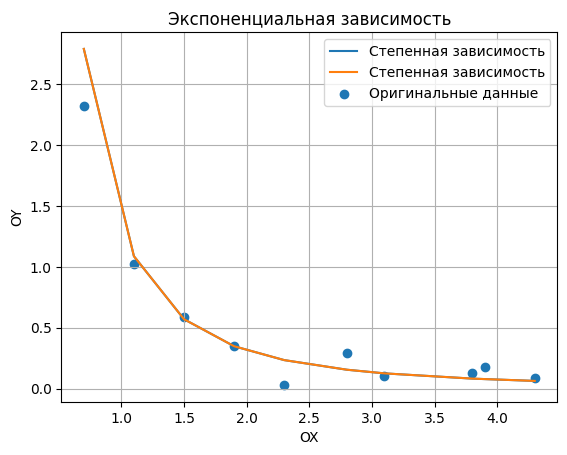

In [82]:
# строим график
plt.plot(x, y_pred(vars), label="Степенная зависимость")
plt.plot(x, y_pred(second), label="Степенная зависимость")
plt.scatter(x, y, label="Оригинальные данные")
plt.grid()
plt.xlabel("OX")
plt.ylabel("OY")
plt.title("Экспоненциальная зависимость")
plt.legend()
plt.show()